In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os
import tqdm

# Hyperparameters
mb_size = 64
Z_dim = 100
h_dim = 128
lr = 1e-3
X_dim = 784  # 28 x 28
y_dim = 10   # number of classes

# Data loading
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # Flatten image to 784
])

train_dataset = datasets.MNIST(root="../MNIST", train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=mb_size, shuffle=True)

# Xavier Init
def xavier_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)

# Generator
class Generator(nn.Module):
    def __init__(self, z_dim, y_dim, h_dim, x_dim):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim + y_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, x_dim)
        self.apply(xavier_init)

    def forward(self, z, y):
        inputs = torch.cat([z, y], dim=1)
        h = F.relu(self.fc1(inputs))
        out = torch.sigmoid(self.fc2(h))
        return out

# Discriminator
class Discriminator(nn.Module):
    def __init__(self, x_dim, y_dim, h_dim):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim + y_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, 1)
        self.apply(xavier_init)

    def forward(self, x, y):
        inputs = torch.cat([x, y], dim=1)
        h = F.relu(self.fc1(inputs))
        out = torch.sigmoid(self.fc2(h))
        return out

# Initialize models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
G = Generator(Z_dim, y_dim, h_dim, X_dim).to(device)
D = Discriminator(X_dim, y_dim, h_dim).to(device)

# Optimizers
G_solver = optim.Adam(G.parameters(), lr=lr)
D_solver = optim.Adam(D.parameters(), lr=lr)

# Loss function
loss_fn = nn.BCELoss()

# One-hot encoding helper
def one_hot(labels, num_classes=10):
    return F.one_hot(labels, num_classes=num_classes).float()

# Sample generator
def save_sample(G, epoch, digit):
    G.eval()
    z = torch.randn(16, Z_dim).to(device)
    y = torch.full((16,), digit, dtype=torch.long).to(device)
    y_onehot = one_hot(y, num_classes=y_dim)
    samples = G(z, y_onehot).detach().cpu().numpy()

    fig = plt.figure(figsize=(4, 4))
    gs = gridspec.GridSpec(4, 4)
    gs.update(wspace=0.05, hspace=0.05)

    for i, sample in enumerate(samples):
        ax = plt.subplot(gs[i])
        plt.axis("off")
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_aspect("equal")
        plt.imshow(sample.reshape(28, 28), cmap="Greys_r")

    os.makedirs("out_cgan", exist_ok=True)
    plt.savefig(f"out_cgan/epoch_{epoch}_digit_{digit}.png", bbox_inches="tight")
    plt.close(fig)

# Training
epochs = 100
for epoch in range(epochs):
    for X_real, y_real in tqdm.tqdm(train_loader):
        X_real = X_real.to(device)
        y_real = one_hot(y_real.to(device), y_dim)

        z = torch.randn(X_real.size(0), Z_dim).to(device)
        y_fake = torch.randint(0, 10, (X_real.size(0),), device=device)
        y_fake_onehot = one_hot(y_fake, y_dim)

        # Train Discriminator
        G_sample = G(z, y_fake_onehot)
        D_real = D(X_real, y_real)
        D_fake = D(G_sample.detach(), y_fake_onehot)

        D_loss_real = loss_fn(D_real, torch.ones_like(D_real))
        D_loss_fake = loss_fn(D_fake, torch.zeros_like(D_fake))
        D_loss = D_loss_real + D_loss_fake

        D_solver.zero_grad()
        D_loss.backward()
        D_solver.step()

        # Train Generator
        z = torch.randn(X_real.size(0), Z_dim).to(device)
        y_fake = torch.randint(0, 10, (X_real.size(0),), device=device)
        y_fake_onehot = one_hot(y_fake, y_dim)
        G_sample = G(z, y_fake_onehot)
        D_fake = D(G_sample, y_fake_onehot)

        G_loss = loss_fn(D_fake, torch.ones_like(D_fake))

        G_solver.zero_grad()
        G_loss.backward()
        G_solver.step()

    print(f"Epoch {epoch}: D_loss={D_loss.item():.4f}, G_loss={G_loss.item():.4f}")

    if epoch % 10 == 0:
        save_sample(G, epoch, digit=3)  # Change this to generate different digits


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.35MB/s]
100%|██████████| 938/938 [00:14<00:00, 64.75it/s]


Epoch 0: D_loss=0.0488, G_loss=4.8373


100%|██████████| 938/938 [00:14<00:00, 63.82it/s]


Epoch 1: D_loss=0.0623, G_loss=4.8736


100%|██████████| 938/938 [00:14<00:00, 66.51it/s]


...

Epoch 97: D_loss=0.8271, G_loss=1.6179


100%|██████████| 938/938 [00:14<00:00, 65.01it/s]


Epoch 98: D_loss=1.1059, G_loss=1.7763


100%|██████████| 938/938 [00:14<00:00, 64.50it/s]

Epoch 99: D_loss=0.6909, G_loss=1.8794


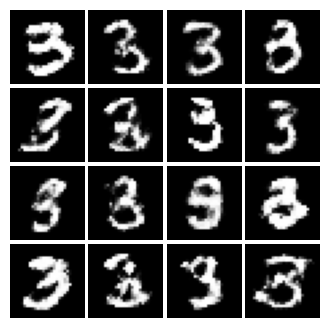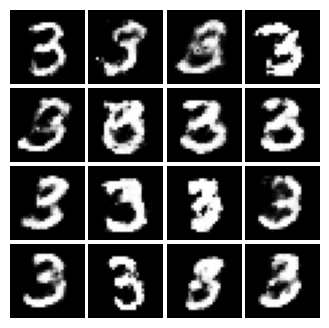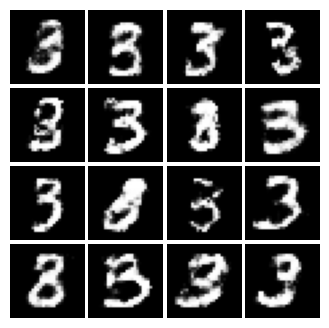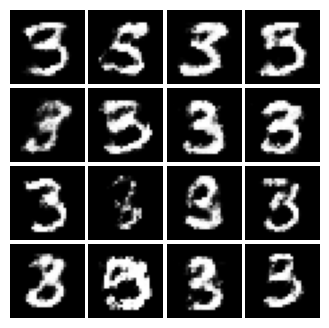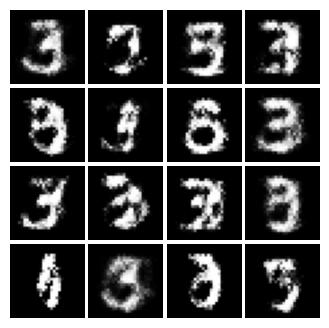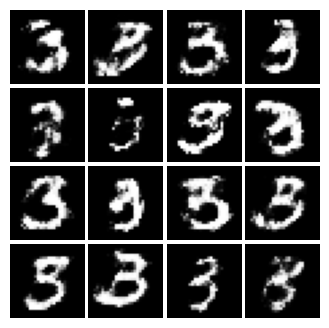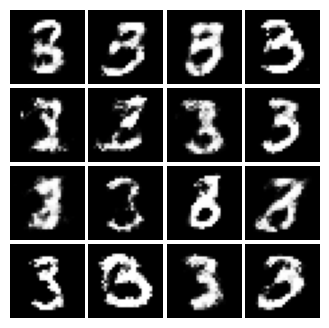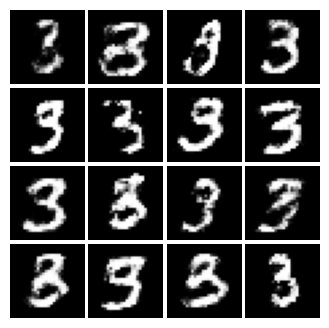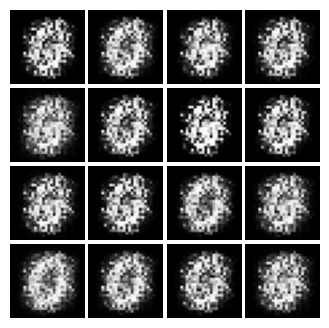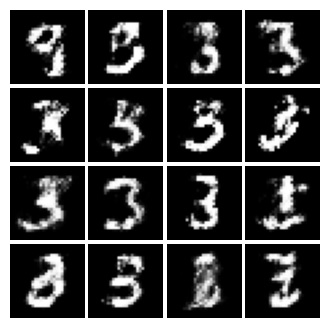